In [ ]:
import geopandas as gpd
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
import importlib
import ntl_functions

importlib.reload(ntl_functions)
from ntl_functions import plot_NASA_NTL, filter_dataset_by_bounding_box


In [ ]:
somaliland_shp = gpd.read_file(
    "../data/Combined_Datasets/Somaliland_with_berbera/somaliland_with_berbera.shp"
)

SL_Berbera_VNP46A4_EY_2012_24 = xr.open_dataset("../data/NTL_Data_A4/141225_SL_Berbera_VNP46A4_EY_2012_24.nc")

logged_NTL = xr.where(
    SL_Berbera_VNP46A4_EY_2012_24.isnull(), 
    np.nan,
    xr.where(
        SL_Berbera_VNP46A4_EY_2012_24 > 0,
        np.log(SL_Berbera_VNP46A4_EY_2012_24),
        0
    )
)

#Cities
HGA = gpd.read_file("../data/Combined_Datasets/Hargeisa_shp/HGA.shp")
Berbera = gpd.read_file("../data/Combined_Datasets/Berbera_shp/Berbera.shp")
Burao = gpd.read_file("../data/Combined_Datasets/Burao_shp/Burao.shp")
Boroma = gpd.read_file("../data/Combined_Datasets/Boroma_shp/Boroma.shp")
Erigavo = gpd.read_file("../data/Combined_Datasets/Erigavo_shp/Erigavo.shp")
Las_Anod = gpd.read_file("../data/Combined_Datasets/Las_Anod_shp/Las_Anod.shp")

c:\Users\samsa\Documents\NTL_Somaliland\venv\Lib\site-packages\xarray\computation\apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


# Data Processing

In [ ]:
# For graphing
HGA_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, HGA)
Berbera_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Berbera)
Burao_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Burao)
Boroma_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Boroma)
Erigavo_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Erigavo)
Las_Anod_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Las_Anod)

# For graphing
log_HGA_NTL = filter_dataset_by_bounding_box(logged_NTL, HGA)
log_Berbera_NTL = filter_dataset_by_bounding_box(logged_NTL, Berbera)
log_Burao_NTL = filter_dataset_by_bounding_box(logged_NTL, Burao)
log_Boroma_NTL = filter_dataset_by_bounding_box(logged_NTL, Boroma)
log_Erigavo_NTL = filter_dataset_by_bounding_box(logged_NTL, Erigavo)
log_Las_Anod_NTL = filter_dataset_by_bounding_box(logged_NTL, Las_Anod)


## Plotting Urban Areas

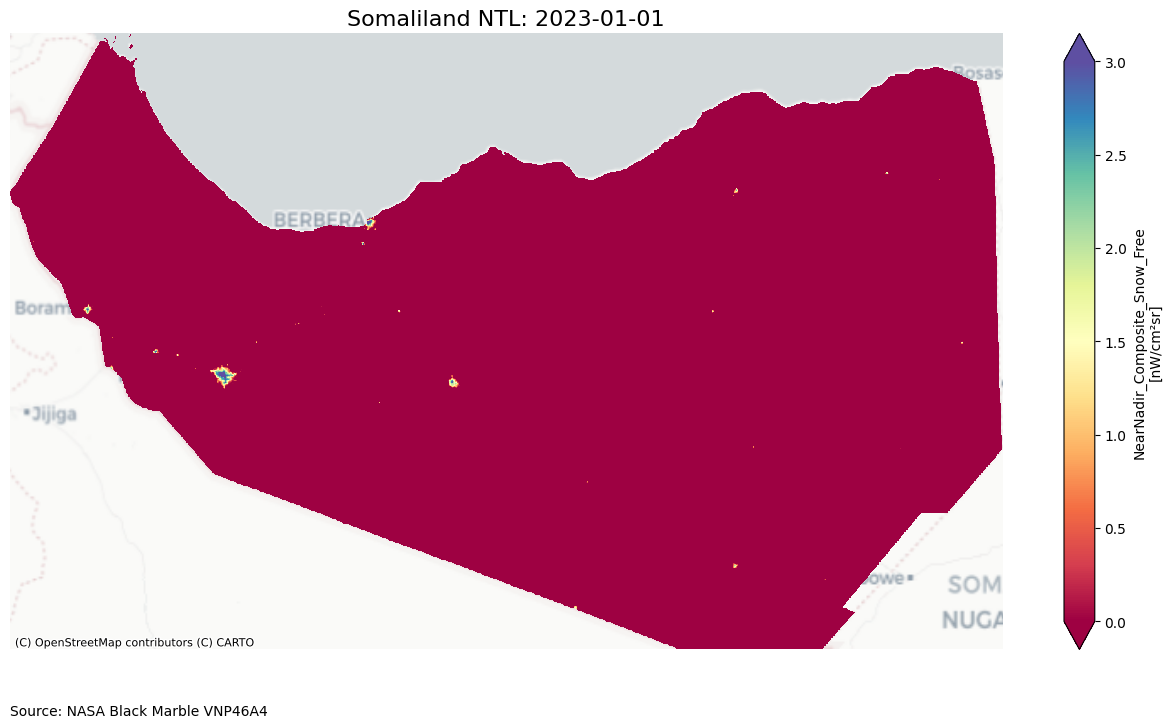

In [11]:
plot_NASA_NTL(logged_NTL, somaliland_shp, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0, vmax = 3)
plt.savefig(f'../output/Graphics/SL_2023_logged.png', dpi=300, bbox_inches='tight')  

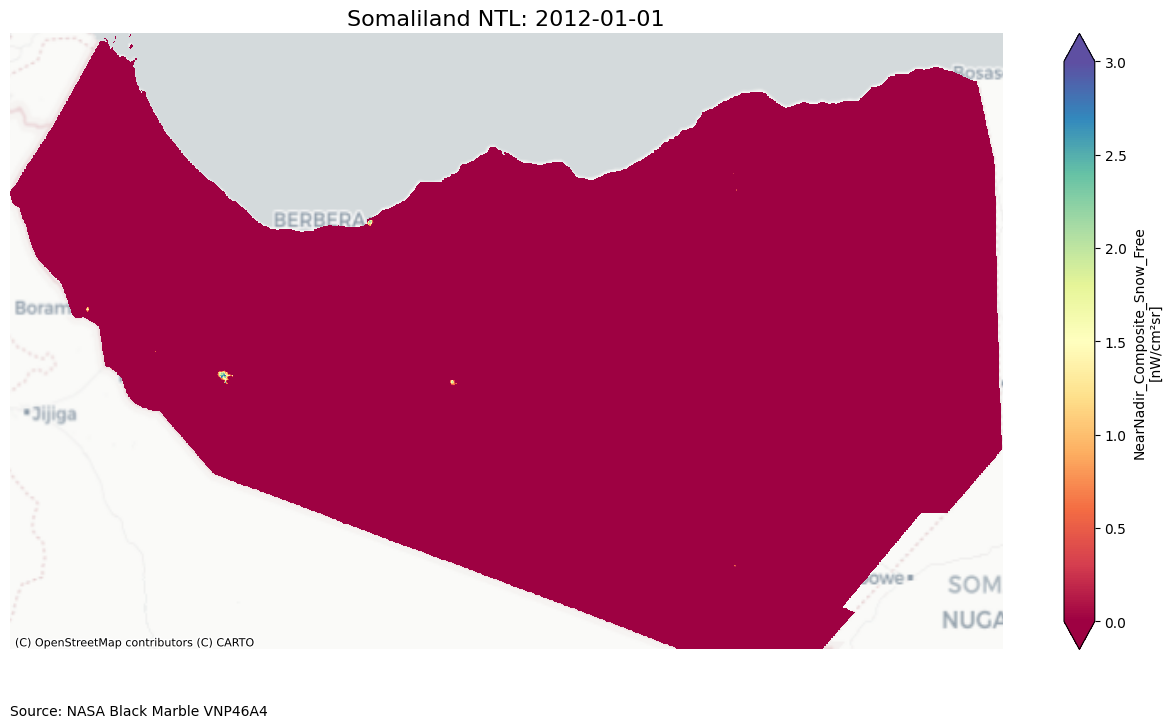

In [12]:
plot_NASA_NTL(logged_NTL, somaliland_shp, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0, vmax = 3)
plt.savefig(f'../output/Graphics/SL_2012_logged.png', dpi=300, bbox_inches='tight')  

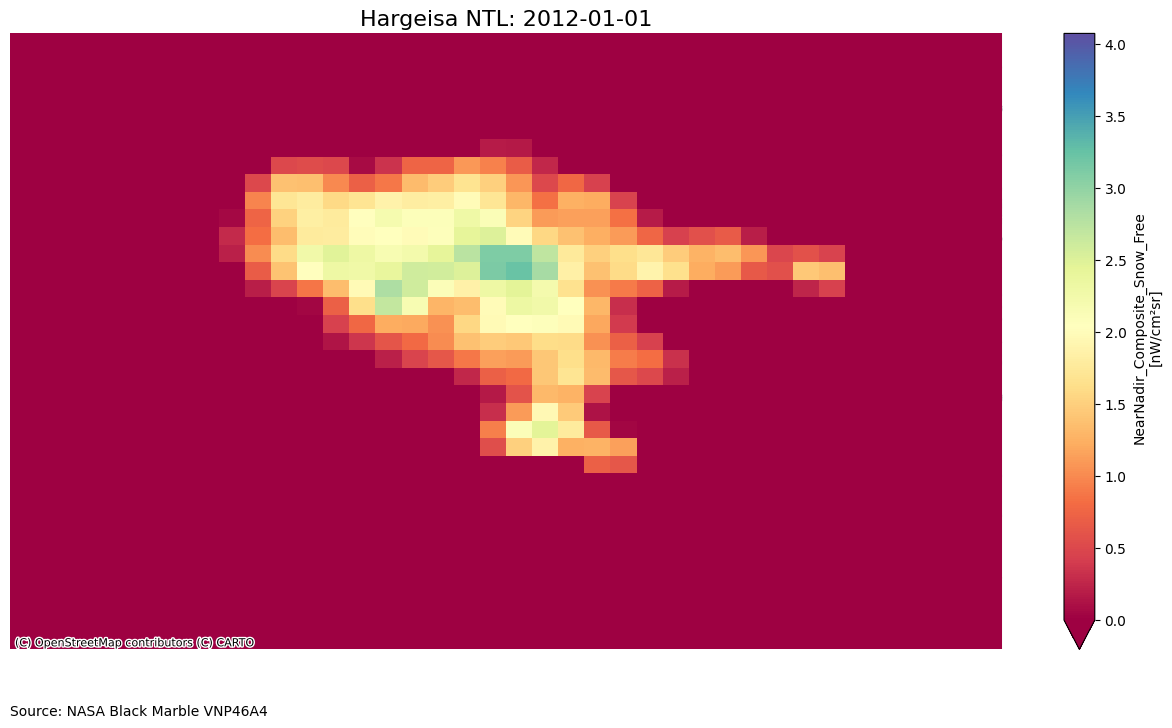

In [13]:
plot_NASA_NTL(log_HGA_NTL, HGA, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Hargeisa NTL",
              robust = False, vmin=0, vmax = log_HGA_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/HGA_2012.png', dpi=300, bbox_inches='tight')  

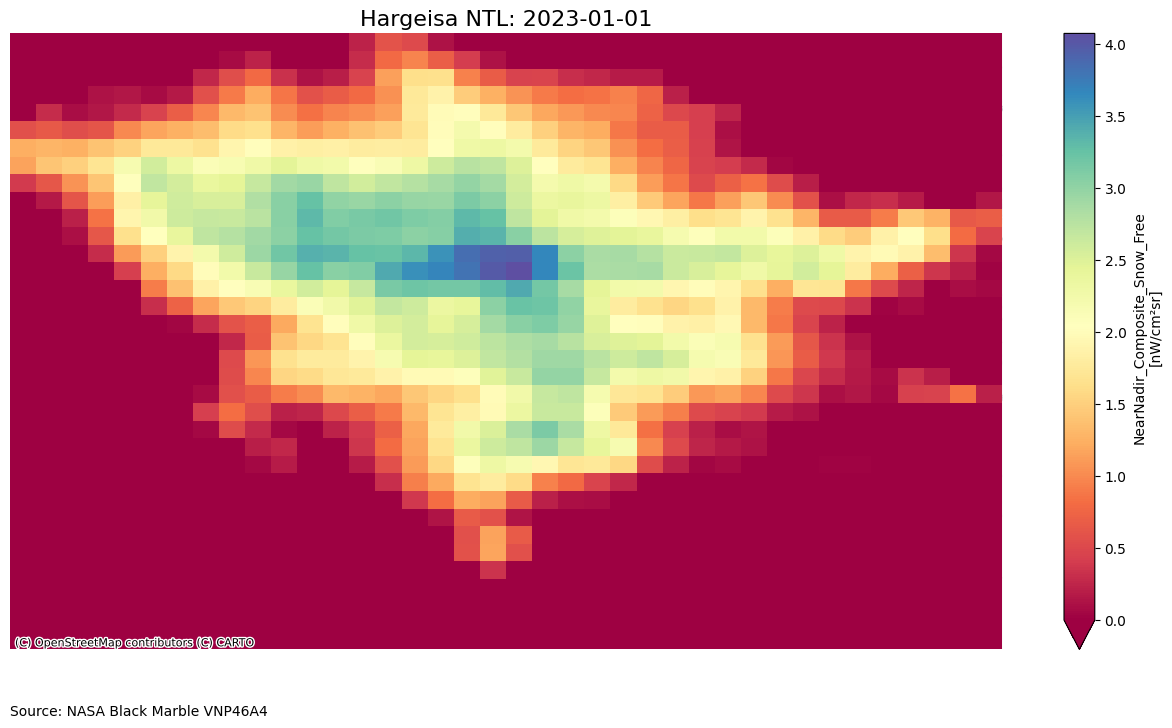

In [14]:
plot_NASA_NTL(log_HGA_NTL, HGA, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Hargeisa NTL",
              robust = False, vmin=0, vmax = log_HGA_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/HGA_2023.png', dpi=300, bbox_inches='tight')  

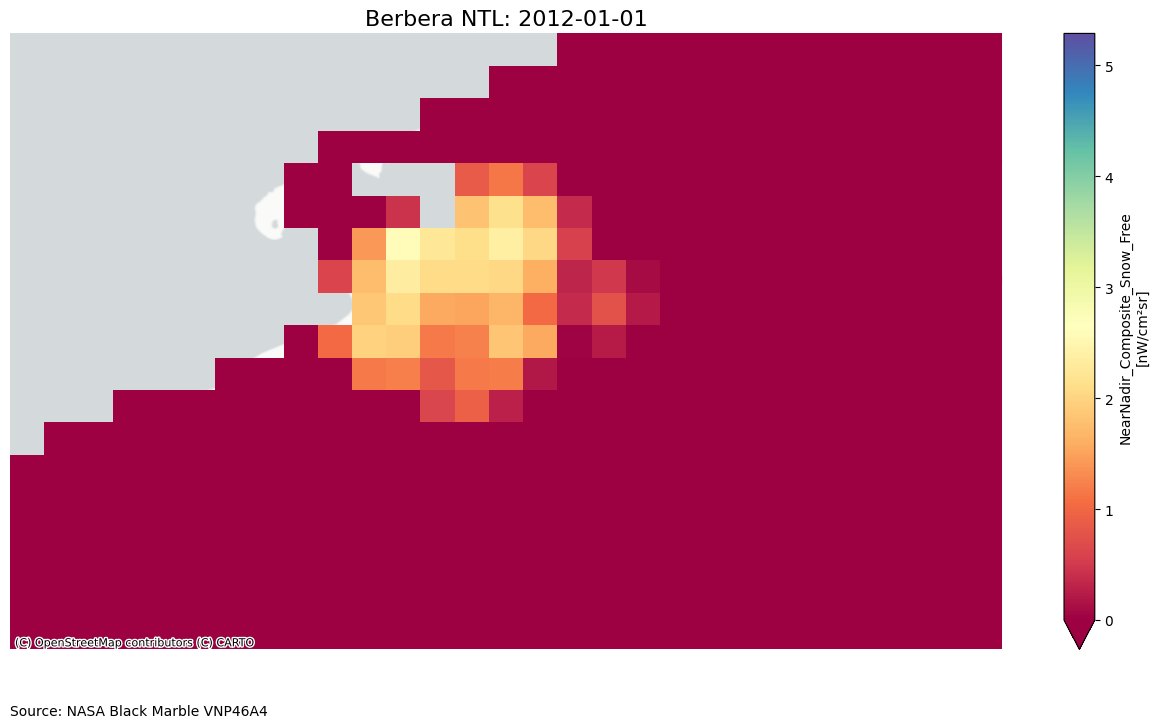

In [15]:
plot_NASA_NTL(log_Berbera_NTL, Berbera, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Berbera NTL",
              robust = False, vmin=0, vmax = log_Berbera_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Berbera_2012.png', dpi=300, bbox_inches='tight')  

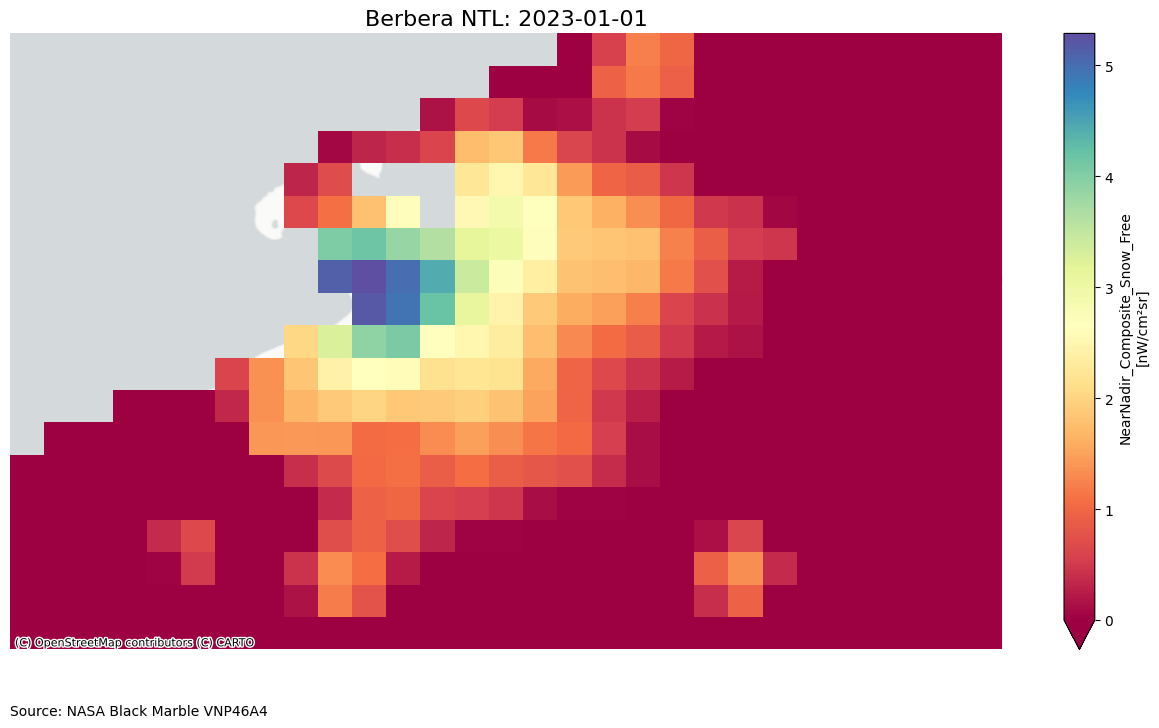

In [16]:
plot_NASA_NTL(log_Berbera_NTL, Berbera, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Berbera NTL",
              robust = False, vmin=0, vmax = log_Berbera_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Berbera_2023.png', dpi=300, bbox_inches='tight')  

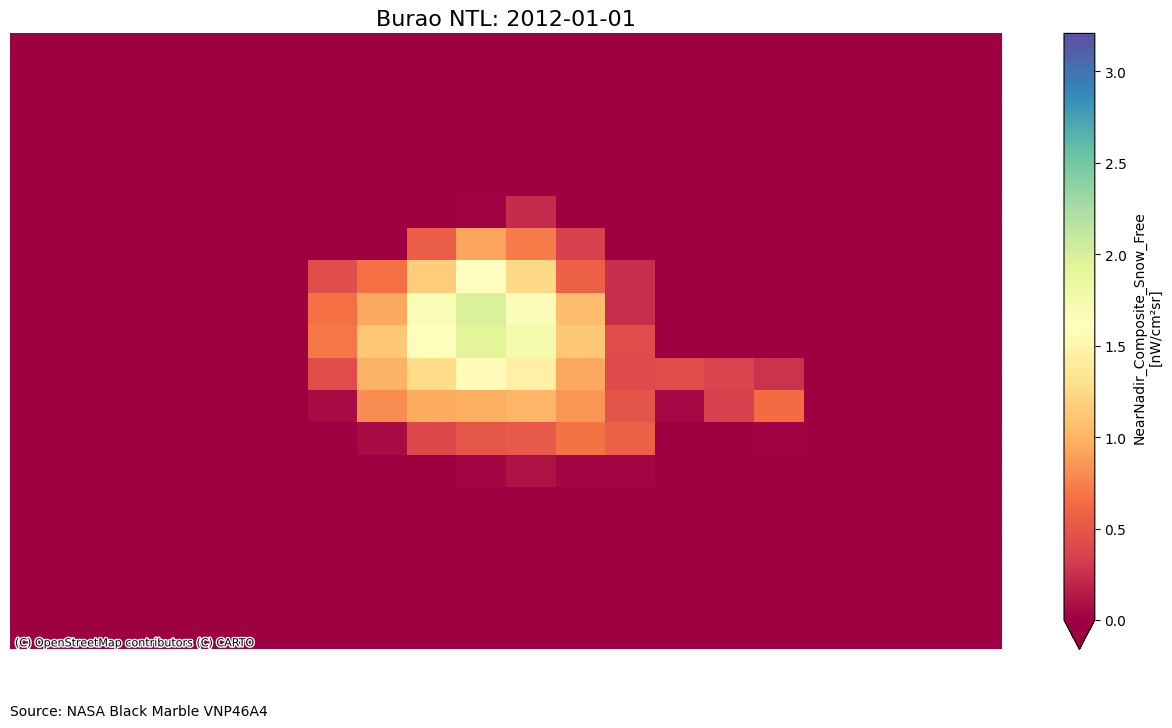

In [17]:
plot_NASA_NTL(log_Burao_NTL, Burao, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Burao NTL",
              robust = False, vmin=0, vmax = log_Burao_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Burao_2012.png', dpi=300, bbox_inches='tight')  

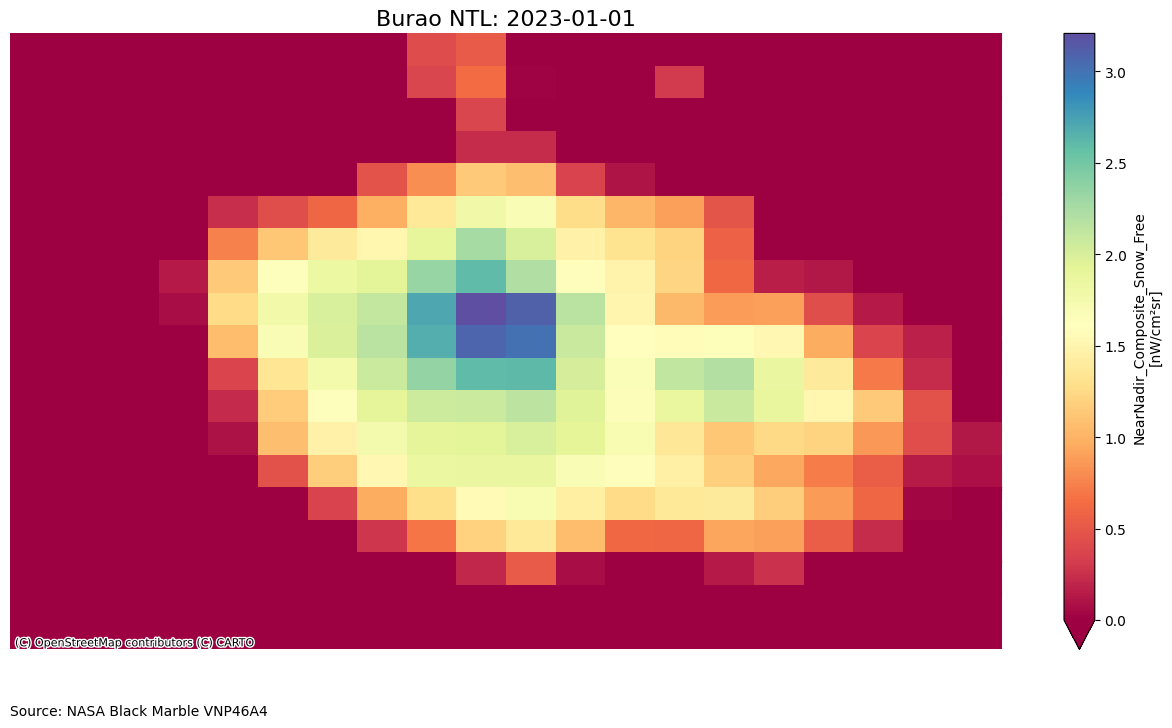

In [18]:
plot_NASA_NTL(log_Burao_NTL, Burao, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Burao NTL",
              robust = False, vmin=0, vmax = log_Burao_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Burao_2023.png', dpi=300, bbox_inches='tight')  

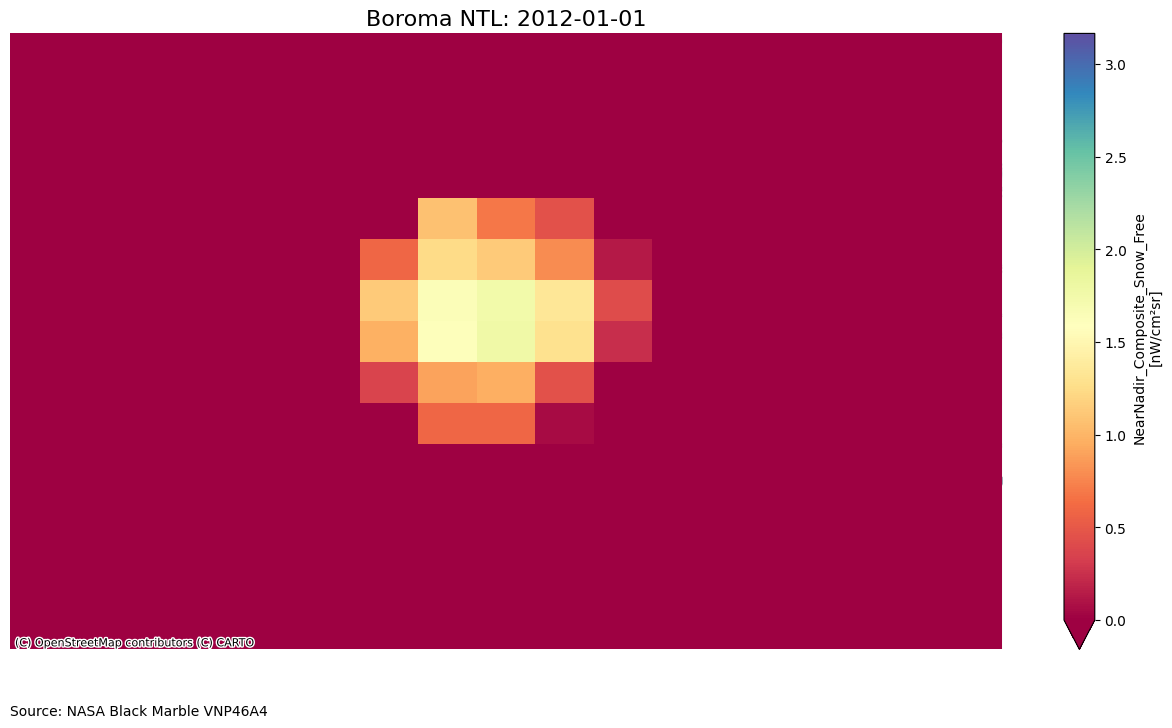

In [19]:
plot_NASA_NTL(log_Boroma_NTL, Boroma, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Boroma NTL",
              robust = False, vmin=0, vmax = log_Boroma_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Boroma_2012.png', dpi=300, bbox_inches='tight')  

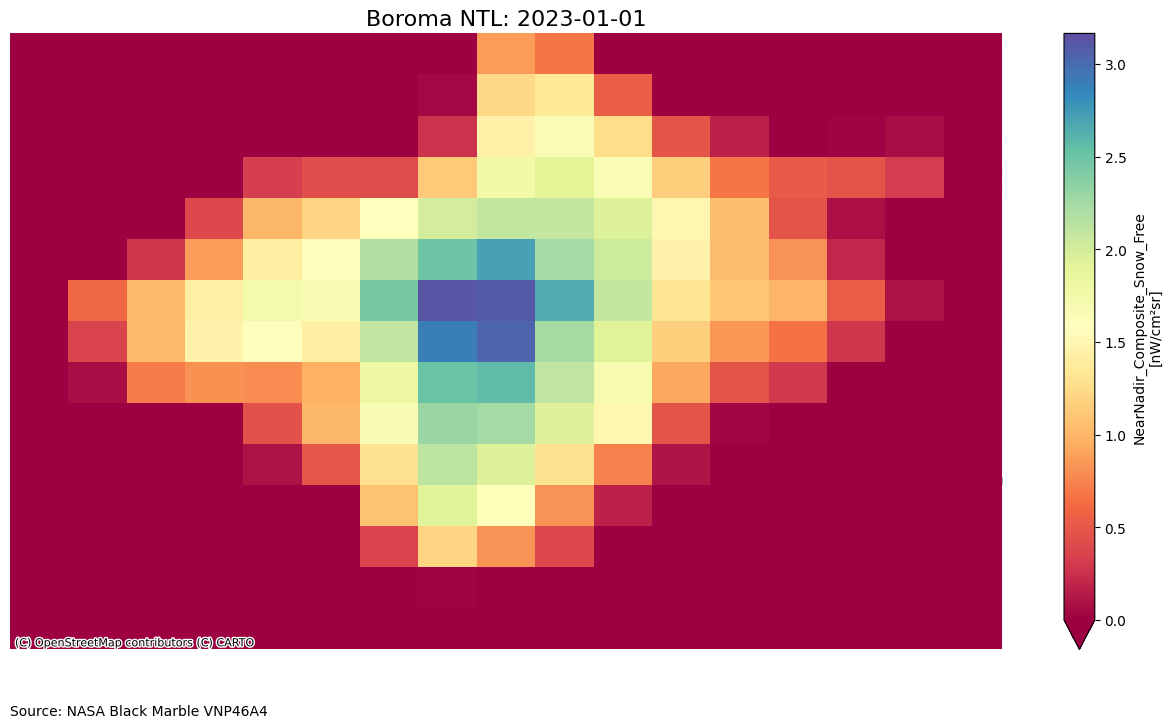

In [20]:
plot_NASA_NTL(log_Boroma_NTL, Boroma, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Boroma NTL",
              robust = False, vmin=0, vmax = log_Boroma_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Boroma_2023.png', dpi=300, bbox_inches='tight')  

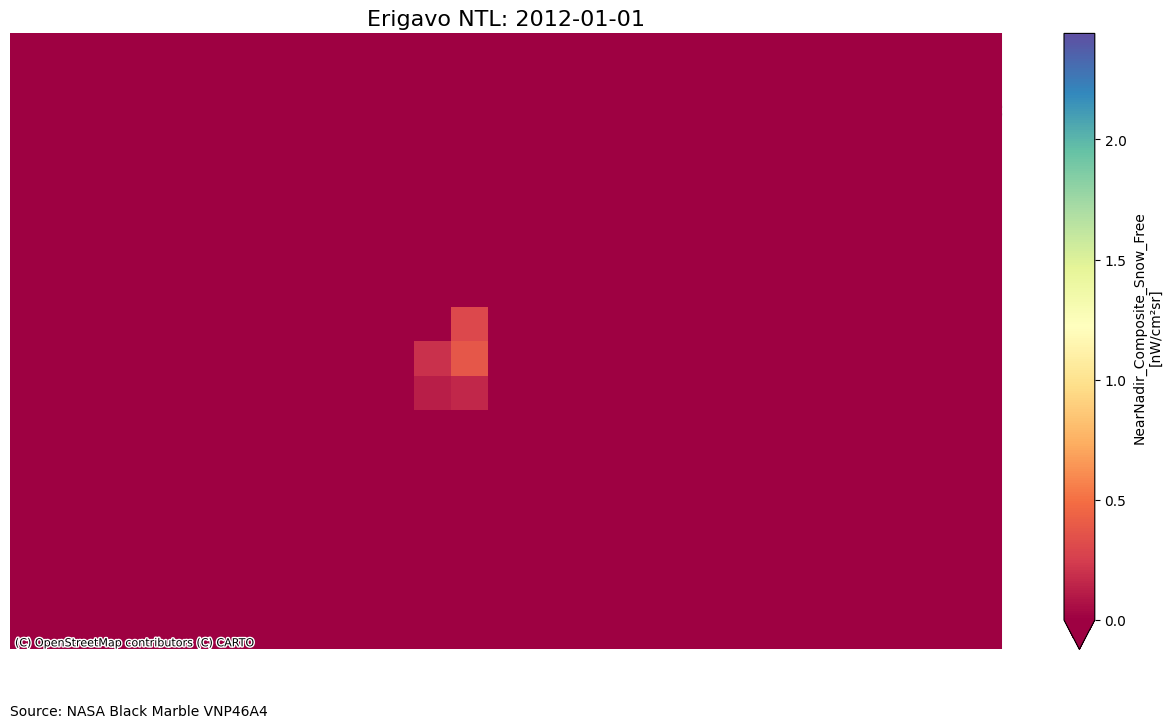

In [21]:
plot_NASA_NTL(log_Erigavo_NTL, Erigavo, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Erigavo NTL",
              robust = False, vmin=0, vmax = log_Erigavo_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Erigavo_2012.png', dpi=300, bbox_inches='tight')  

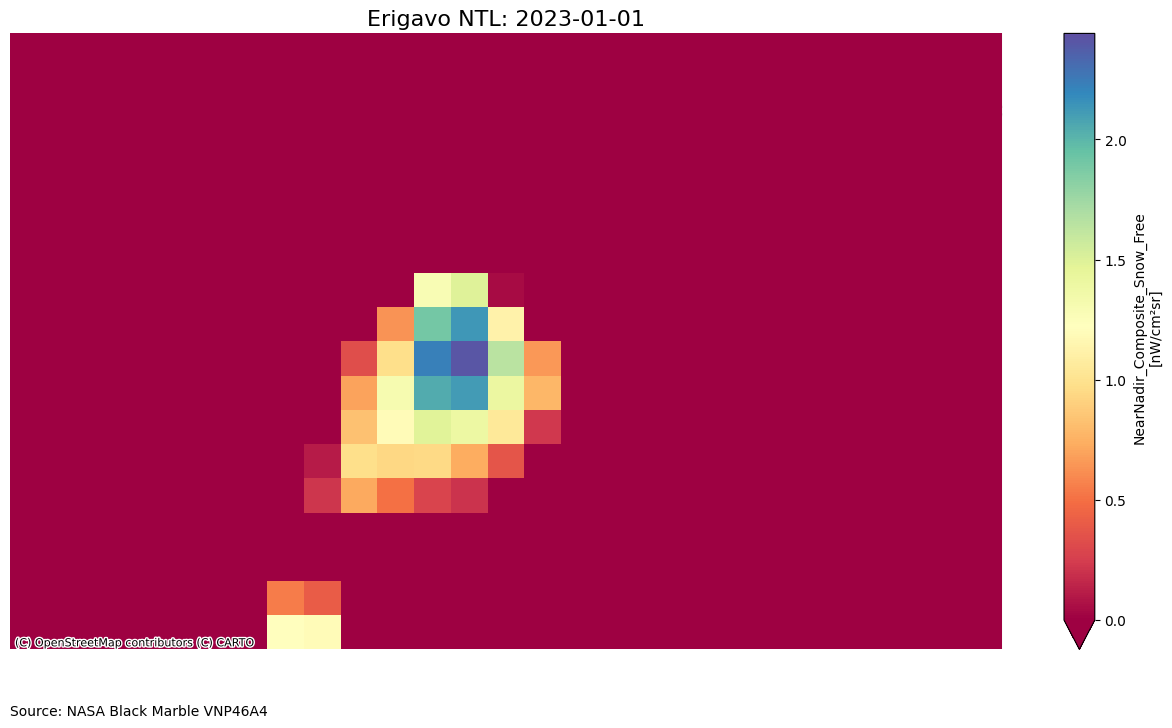

In [22]:
plot_NASA_NTL(log_Erigavo_NTL, Erigavo, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Erigavo NTL",
              robust = False, vmin=0, vmax = log_Erigavo_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Erigavo_2023.png', dpi=300, bbox_inches='tight')  

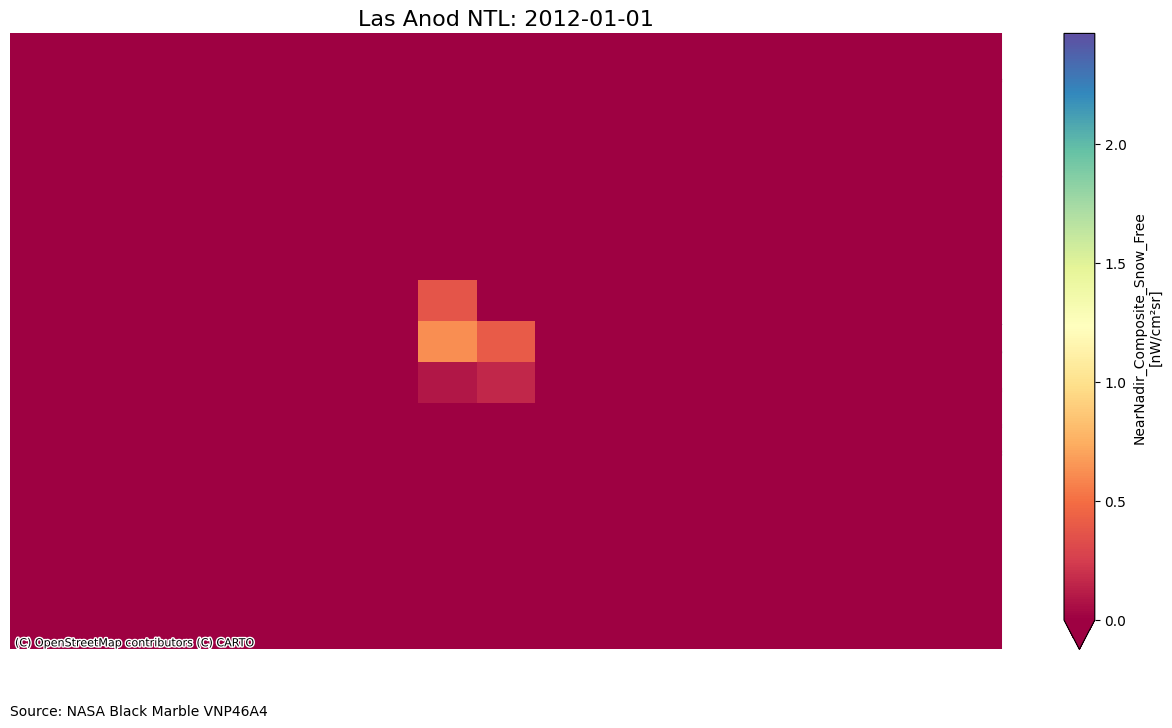

In [23]:
plot_NASA_NTL(log_Las_Anod_NTL, Las_Anod, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Las Anod NTL",
              robust = False, vmin=0, vmax = log_Las_Anod_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Las_Anod_2012.png', dpi=300, bbox_inches='tight')  

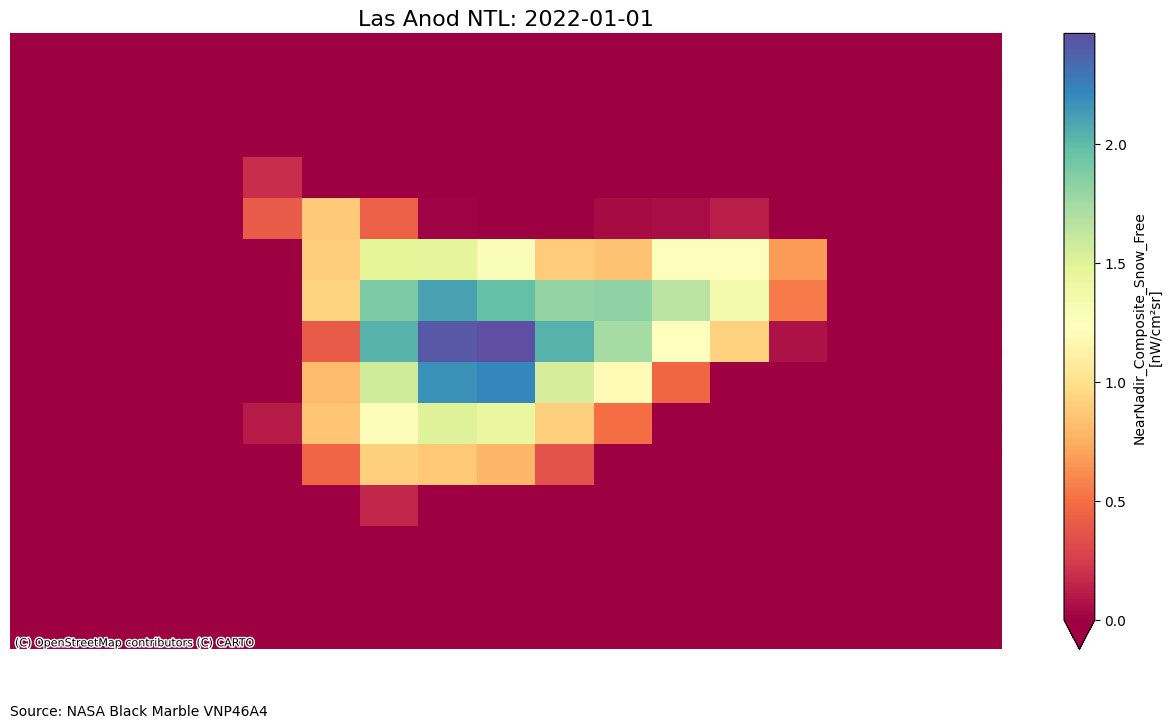

In [ ]:
plot_NASA_NTL(log_Las_Anod_NTL, Las_Anod, date = "2022-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Las Anod NTL",
              robust = False, vmin=0, vmax = log_Las_Anod_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Las_Anod_2022.png', dpi=300, bbox_inches='tight')  

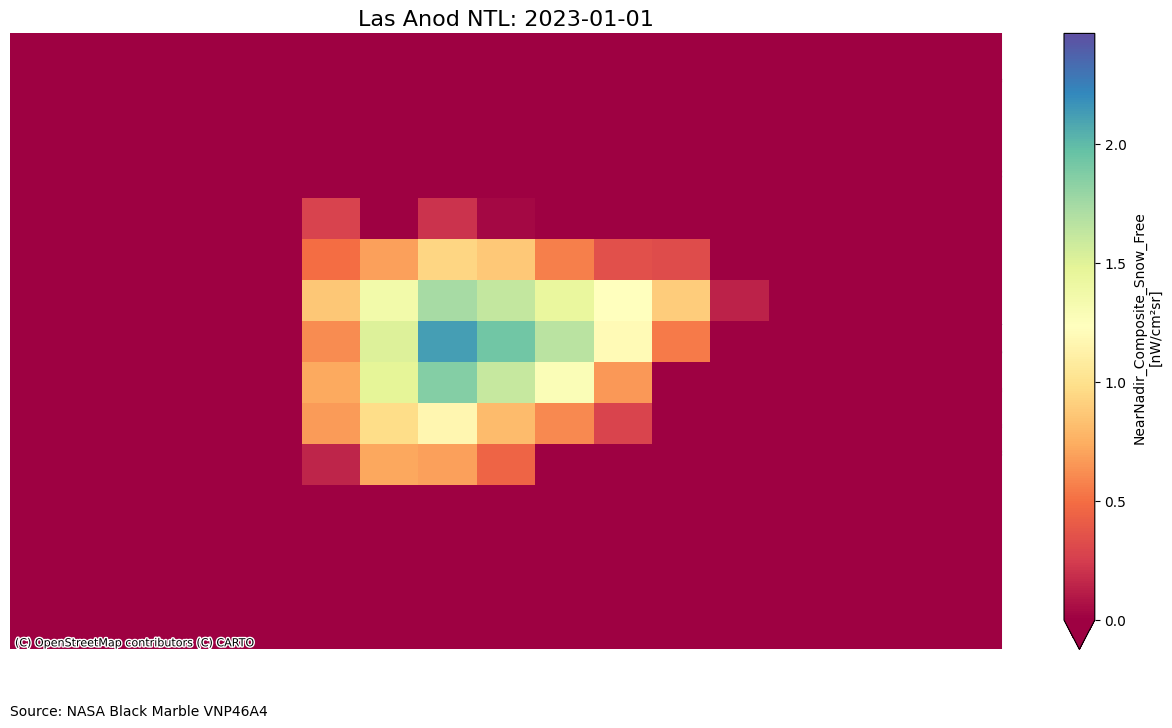

In [24]:
plot_NASA_NTL(log_Las_Anod_NTL, Las_Anod, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Las Anod NTL",
              robust = False, vmin=0, vmax = log_Las_Anod_NTL["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Las_Anod_2023.png', dpi=300, bbox_inches='tight')  